In [17]:
# =============================================================================
# CHAPTER 4.5 — EXTERNAL VALIDATION: STUFFMART CUSTOMER CONVERSION DATASET
#
# This notebook implements the external robustness check described in
# Chapter 3 Section 3.2.1 of the dissertation.
#
# PURPOSE:
#   Test whether the directional finding from X Education holds in a
#   structurally different conversion context:
#   Does S1 (ML only) outperform S3_uncapped (hard priority without cap)?
#
# SCOPE:
#   Three systems only: S1, S2, S3 (capped and uncapped)
#   No S4 soft adjustment — not implemented for secondary dataset
#   No bootstrap — this is directional robustness checking, not inference
#   Results are compared directionally to X Education primary findings
#
# DATASET:
#   Stuffmart Customer Conversion Dataset (Kaggle)
#   100,000 synthetic leads | ~1.65% conversion rate | Pakistan retail context
#   Two CSVs: training (customer_conversion_traing_dataset.csv)
#             testing  (customer_conversion_testing_dataset.csv)
#
# UPLOAD INSTRUCTIONS:
#   Upload both CSVs to your Google Drive under:
#   /content/drive/MyDrive/Masters_Constrained_Lead_Qualification/
#   Then mount Drive in Cell SM-00.
#
# IMPORTANT — HARDCODED X EDUCATION NUMBERS:
#   Cell SM-10d contains manually entered X Education results for the
#   cross-dataset comparison chart. These are taken from the final
#   primary notebook (Notebook 15). If the primary results change,
#   update XE_PREC and XE_BASELINE in Cell SM-10d accordingly.
#   They are clearly labelled to make this audit trail transparent.
# =============================================================================



In [18]:

# =============================================================================
# CELL SM-00 — SETUP AND MOUNT DRIVE
# =============================================================================

!pip install xgboost -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

from google.colab import drive
drive.mount('/content/drive')

DRIVE_PATH = '/content/drive/MyDrive/Masters_Constrained_Lead_Qualification/'
TRAIN_FILE = DRIVE_PATH + 'customer_conversion_traing_dataset .csv'
TEST_FILE  = DRIVE_PATH + 'customer_conversion_testing_dataset.csv'

print("Setup complete.")



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Setup complete.


In [19]:

# =============================================================================
# CELL SM-01 — LOAD DATA
# =============================================================================

sm_train_raw = pd.read_csv(TRAIN_FILE)
sm_test_raw  = pd.read_csv(TEST_FILE)

print(f"Training set shape: {sm_train_raw.shape}")
print(f"Test set shape:     {sm_test_raw.shape}")
print(f"\nColumns: {sm_train_raw.columns.tolist()}")
print(f"\nTraining conversion rate: {sm_train_raw['Conversion (Target)'].mean():.4f}")
print(f"Test conversion rate:     {sm_test_raw['Conversion (Target)'].mean():.4f}")
print(f"\nLeadStatus values (train):\n{sm_train_raw['LeadStatus'].value_counts()}")
print(f"\nLeadSource values (train):\n{sm_train_raw['LeadSource'].value_counts()}")
print(f"\nPaymentHistory values (train):\n{sm_train_raw['PaymentHistory'].value_counts()}")



Training set shape: (100000, 19)
Test set shape:     (26145, 19)

Columns: ['LeadID', 'Age', 'Gender', 'Location', 'LeadSource', 'TimeSpent (minutes)', 'PagesViewed', 'LeadStatus', 'EmailSent', 'DeviceType', 'ReferralSource', 'FormSubmissions', 'Downloads', 'CTR_ProductPage', 'ResponseTime (hours)', 'FollowUpEmails', 'SocialMediaEngagement', 'PaymentHistory', 'Conversion (Target)']

Training conversion rate: 0.0165
Test conversion rate:     0.0158

LeadStatus values (train):
LeadStatus
Cold    33435
Hot     33288
Warm    33277
Name: count, dtype: int64

LeadSource values (train):
LeadSource
Organic         25257
Social Media    25030
Email           24947
Referral        24766
Name: count, dtype: int64

PaymentHistory values (train):
PaymentHistory
Good          50111
No Payment    49889
Name: count, dtype: int64


In [20]:

# =============================================================================
# CELL SM-02 — PRE-PROCESSING
#
# The Stuffmart dataset has no missing values and no duplicates (confirmed
# in the EDA notebook submitted alongside this study).
#
# POLICY RULE PROXIES (see Chapter 3 Section 3.2.6):
#
#   H1 proxy: PaymentHistory = 'No Payment'
#     NOTE: This is NOT a contactability constraint (unlike X Education's
#     Do Not Email / Do Not Call). It is a commercial risk / low-commitment
#     exclusion proxy. It applies the same governance principle — filtering
#     leads where a specific operational concern exists regardless of
#     conversion probability — but addresses financial risk rather than
#     contact permissibility. This distinction is acknowledged explicitly
#     in the dissertation (Chapter 3 and Chapter 4.5).
#
#   H2 proxy: TimeSpent (minutes) = 0 AND PagesViewed = 0
#     Structurally identical to X Education H2. Zero engagement signal.
#
#   P1 proxy: LeadStatus = 'Hot'
#     CRM-assigned highest-intent tier. Directly analogous to high-intent
#     activity signals (Olark Chat, Email Link Clicked) in X Education.
#
#   P2 proxy: LeadSource = 'Referral'
#     Deliberate inbound channel. Analogous to Landing Page Submission.
#
# These proxies are operationally analogous to X Education rules but
# not semantically equivalent. See Chapter 3 Section 3.2.6.
#
# This notebook uses OneHotEncoder inside a Pipeline (consistent with
# the primary X Education methodology) rather than the LabelEncoder
# used in the EDA submission, ensuring cleaner train/test separation.
# =============================================================================

TARGET = 'Conversion (Target)'

# Policy column constants
SM_H1_COL   = 'PaymentHistory'
SM_H1_VALUE = 'No Payment'
SM_H2_COL1  = 'TimeSpent (minutes)'
SM_H2_COL2  = 'PagesViewed'
SM_P1_COL   = 'LeadStatus'
SM_P1_VALUE = 'Hot'
SM_P2_COL   = 'LeadSource'
SM_P2_VALUE = 'Referral'

POLICY_COLS = [SM_H1_COL, SM_H2_COL1, SM_H2_COL2, SM_P1_COL, SM_P2_COL]


def preprocess_stuffmart(df):
    """Drop LeadID (non-predictive identifier). Return cleaned df."""
    df = df.copy()
    df = df.drop(columns=['LeadID'], errors='ignore')
    return df


sm_train = preprocess_stuffmart(sm_train_raw)
sm_test  = preprocess_stuffmart(sm_test_raw)

# Preserve raw policy columns from the TEST set before any encoding.
# Policy rules operate on original string values — encoding would lose them.
sm_policy_test = sm_test[POLICY_COLS].copy().reset_index(drop=True)

print("Policy columns preserved from test set.")
print(f"\nH1 (PaymentHistory = No Payment) in test: "
      f"{(sm_policy_test[SM_H1_COL] == SM_H1_VALUE).sum():,}")
print(f"H2 (TimeSpent=0 AND PagesViewed=0) in test: "
      f"{((sm_policy_test[SM_H2_COL1] == 0) & (sm_policy_test[SM_H2_COL2] == 0)).sum():,}")
print(f"P1 (LeadStatus=Hot) in test: "
      f"{(sm_policy_test[SM_P1_COL] == SM_P1_VALUE).sum():,}")
print(f"P2 (LeadSource=Referral) in test: "
      f"{(sm_policy_test[SM_P2_COL] == SM_P2_VALUE).sum():,}")




Policy columns preserved from test set.

H1 (PaymentHistory = No Payment) in test: 13,123
H2 (TimeSpent=0 AND PagesViewed=0) in test: 0
P1 (LeadStatus=Hot) in test: 8,769
P2 (LeadSource=Referral) in test: 6,501


In [21]:

# =============================================================================
# CELL SM-03 — PREPROCESSING PIPELINE
#
# The dataset comes pre-split into two CSVs. We use the provided split.
# This is consistent with the EDA notebook structure submitted alongside
# this study. Stratified splitting is not required here — the files
# already exist. We verify conversion rates are comparable across splits.
# =============================================================================

sm_y_train = sm_train[TARGET]
sm_X_train = sm_train.drop(columns=[TARGET])

sm_y_test  = sm_test[TARGET].reset_index(drop=True)
sm_X_test  = sm_test.drop(columns=[TARGET]).reset_index(drop=True)

print(f"Training: X={sm_X_train.shape}, y={sm_y_train.shape}")
print(f"Test:     X={sm_X_test.shape},  y={sm_y_test.shape}")
print(f"Training conversion rate: {sm_y_train.mean():.4f}")
print(f"Test conversion rate:     {sm_y_test.mean():.4f}")

SM_BASELINE_RATE    = sm_y_test.mean()
SM_TOTAL_CONVERTERS = int(sm_y_test.sum())
SM_K                = int(len(sm_y_test) * 0.2)

print(f"\nBaseline conversion rate : {SM_BASELINE_RATE:.4f}  ({SM_BASELINE_RATE*100:.2f}%)")
print(f"Total converters in test : {SM_TOTAL_CONVERTERS:,}")
print(f"K (top 20%)              : {SM_K:,}")

# Class imbalance: scale_pos_weight = negatives / positives in training set
sm_neg = (sm_y_train == 0).sum()
sm_pos = (sm_y_train == 1).sum()
SM_SCALE_POS_WEIGHT = sm_neg / sm_pos
print(f"\nScale_pos_weight : {SM_SCALE_POS_WEIGHT:.1f}  (negatives/positives in train)")
print(f"  A model predicting all-zero achieves "
      f"{(1 - sm_y_test.mean())*100:.1f}% accuracy — accuracy is uninformative here.")

# Feature types
sm_numeric     = sm_X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
sm_categorical = sm_X_train.select_dtypes(include=['object']).columns.tolist()

print(f"\nNumeric features     ({len(sm_numeric)}): {sm_numeric}")
print(f"Categorical features ({len(sm_categorical)}): {sm_categorical}")

# Preprocessing pipeline — consistent with X Education primary methodology
sm_numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])
sm_cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])
sm_preprocessor = ColumnTransformer([
    ('num', sm_numeric_pipe, sm_numeric),
    ('cat', sm_cat_pipe,     sm_categorical),
])


Training: X=(100000, 17), y=(100000,)
Test:     X=(26145, 17),  y=(26145,)
Training conversion rate: 0.0165
Test conversion rate:     0.0158

Baseline conversion rate : 0.0158  (1.58%)
Total converters in test : 413
K (top 20%)              : 5,229

Scale_pos_weight : 59.7  (negatives/positives in train)
  A model predicting all-zero achieves 98.4% accuracy — accuracy is uninformative here.

Numeric features     (10): ['Age', 'TimeSpent (minutes)', 'PagesViewed', 'EmailSent', 'FormSubmissions', 'Downloads', 'CTR_ProductPage', 'ResponseTime (hours)', 'FollowUpEmails', 'SocialMediaEngagement']
Categorical features (7): ['Gender', 'Location', 'LeadSource', 'LeadStatus', 'DeviceType', 'ReferralSource', 'PaymentHistory']


In [22]:

# =============================================================================
# CELL SM-04 — TRAIN MODELS
#
# Same pipeline structure as X Education primary study.
# Logistic Regression (interpretable baseline) and XGBoost (ensemble).
# Both use class weighting to address severe 1.65% imbalance.
#
# ACCURACY WARNING: The EDA notebook reported 99.5% accuracy for Random
# Forest. This figure is entirely uninformative given the 1.65% baseline
# conversion rate — a model predicting all zeros achieves 98.35% accuracy
# automatically. This notebook evaluates on AUC-ROC and Precision@K only,
# consistent with the primary methodology and appropriate for imbalanced
# classification tasks.
# =============================================================================

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# --- Logistic Regression ---
sm_lr_pipe = Pipeline([
    ('preprocessor', sm_preprocessor),
    ('model', LogisticRegression(
        class_weight='balanced',
        max_iter=2000,
        random_state=RANDOM_STATE,
    )),
])
sm_lr_search = GridSearchCV(
    sm_lr_pipe,
    {'model__C': [0.01, 0.1, 1, 10]},
    scoring='roc_auc', cv=cv, n_jobs=-1, verbose=0,
)
sm_lr_search.fit(sm_X_train, sm_y_train)
sm_lr_auc = roc_auc_score(
    sm_y_test, sm_lr_search.predict_proba(sm_X_test)[:, 1]
)
print(f"Logistic Regression  AUC-ROC: {sm_lr_auc:.4f}  "
      f"(best C: {sm_lr_search.best_params_['model__C']})")

# --- XGBoost ---
sm_xgb_pipe = Pipeline([
    ('preprocessor', sm_preprocessor),
    ('model', XGBClassifier(
        eval_metric='logloss',
        random_state=RANDOM_STATE,
        scale_pos_weight=SM_SCALE_POS_WEIGHT,
    )),
])
sm_xgb_search = RandomizedSearchCV(
    sm_xgb_pipe,
    {
        'model__n_estimators':     [100, 200, 300],
        'model__max_depth':        [2, 3, 4, 5],
        'model__learning_rate':    [0.01, 0.05, 0.1],
        'model__subsample':        [0.7, 0.8, 1.0],
        'model__colsample_bytree': [0.7, 0.8, 1.0],
    },
    n_iter=20, scoring='roc_auc', cv=cv,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=0,
)
sm_xgb_search.fit(sm_X_train, sm_y_train)
sm_xgb_auc = roc_auc_score(
    sm_y_test, sm_xgb_search.predict_proba(sm_X_test)[:, 1]
)
print(f"XGBoost              AUC-ROC: {sm_xgb_auc:.4f}  "
      f"(best params: {sm_xgb_search.best_params_})")

# Select best model by AUC-ROC
if sm_xgb_auc >= sm_lr_auc:
    sm_best_model      = sm_xgb_search
    sm_best_model_name = 'XGBoost'
    sm_best_auc        = sm_xgb_auc
else:
    sm_best_model      = sm_lr_search
    sm_best_model_name = 'Logistic Regression'
    sm_best_auc        = sm_lr_auc

print(f"\nSelected scoring engine: {sm_best_model_name}  (AUC-ROC: {sm_best_auc:.4f})")
print(f"X Education comparison:  XGBoost AUC-ROC 0.8725")

# Generate fixed ML probability vector — consumed unchanged by all systems
sm_ml_scores = sm_best_model.predict_proba(sm_X_test)[:, 1]

print(f"\nML score distribution (test set):")
print(f"  Min:    {sm_ml_scores.min():.4f}")
print(f"  Max:    {sm_ml_scores.max():.4f}")
print(f"  Mean:   {sm_ml_scores.mean():.4f}")
print(f"  Median: {np.median(sm_ml_scores):.4f}")



Logistic Regression  AUC-ROC: 0.9818  (best C: 10)
XGBoost              AUC-ROC: 1.0000  (best params: {'model__subsample': 0.8, 'model__n_estimators': 300, 'model__max_depth': 3, 'model__learning_rate': 0.1, 'model__colsample_bytree': 0.8})

Selected scoring engine: XGBoost  (AUC-ROC: 1.0000)
X Education comparison:  XGBoost AUC-ROC 0.8725

ML score distribution (test set):
  Min:    0.0000
  Max:    0.9993
  Mean:   0.0210
  Median: 0.0000


In [23]:
# =============================================================================
# CELL SM-04b — LEAKAGE DIAGNOSTIC
#
# XGBoost achieved AUC-ROC = 1.0000. This is not possible on a genuine
# dataset without data leakage. This cell identifies which features are
# causing perfect prediction and decides whether to exclude them.
#
# The most likely culprit is LeadStatus (Cold/Hot/Warm), which the EDA
# notebook showed is strongly associated with conversion. In a synthetic
# dataset, LeadStatus may have been generated directly from the conversion
# label rather than representing a genuine CRM state prior to conversion.
#
# INSERT THIS CELL BETWEEN SM-04 AND SM-05.
# =============================================================================

print("=== LEAKAGE DIAGNOSTIC ===\n")

# Check conversion rate by LeadStatus
print("Conversion rate by LeadStatus (training set):")
ls_check = sm_train_raw.groupby('LeadStatus')['Conversion (Target)'].agg(
    ['mean', 'sum', 'count']
).rename(columns={'mean': 'conv_rate', 'sum': 'converters', 'count': 'total'})
ls_check['conv_rate'] = ls_check['conv_rate'].round(4)
print(ls_check)

# Check conversion rate by Location
print("\nConversion rate by Location (training set):")
loc_check = sm_train_raw.groupby('Location')['Conversion (Target)'].agg(
    ['mean', 'sum', 'count']
).rename(columns={'mean': 'conv_rate', 'sum': 'converters', 'count': 'total'})
loc_check['conv_rate'] = loc_check['conv_rate'].round(4)
print(loc_check.sort_values('conv_rate', ascending=False))

# Check if any numeric feature perfectly separates the classes
print("\nCorrelation of numeric features with target (training set):")
num_corr = sm_train_raw[sm_numeric + ['Conversion (Target)']].corr()[
    'Conversion (Target)'
].drop('Conversion (Target)').abs().sort_values(ascending=False)
print(num_corr.round(4))

# Decision logic
hot_rate = ls_check.loc['Hot', 'conv_rate'] if 'Hot' in ls_check.index else 0
cold_rate = ls_check.loc['Cold', 'conv_rate'] if 'Cold' in ls_check.index else 0

print(f"\nHot lead conversion rate:  {hot_rate:.4f}")
print(f"Cold lead conversion rate: {cold_rate:.4f}")

if hot_rate > 0.9 or (hot_rate > 0.1 and cold_rate < 0.001):
    print("""
  ⚠ LEAKAGE DETECTED: LeadStatus appears to be generated from the
    conversion label in this synthetic dataset. Hot leads convert at
    near-100% and Cold/Warm leads convert at near-0%.

  DECISION: LeadStatus must be EXCLUDED from the ML model feature set.
    It will be retained as a policy-rule-only input (P1 proxy), consistent
    with how Do Not Email/Do Not Call are excluded in the primary study.
    This exclusion is methodologically correct and improves comparability
    with X Education, where policy signals are separated from model features.

  ACTION: Re-run SM-03 and SM-04 after updating MODEL_EXCLUDE below.
""")
    LEAKAGE_CONFIRMED = True
else:
    print("  ✓ No obvious label leakage detected in LeadStatus.")
    LEAKAGE_CONFIRMED = False



=== LEAKAGE DIAGNOSTIC ===

Conversion rate by LeadStatus (training set):
            conv_rate  converters  total
LeadStatus                              
Cold           0.0098         329  33435
Hot            0.0295         982  33288
Warm           0.0101         336  33277

Conversion rate by Location (training set):
            conv_rate  converters  total
Location                                
Islamabad      0.0553         555  10039
Karachi        0.0545         545   9993
Lahore         0.0544         547  10057
Faisalabad     0.0000           0  10196
Gujranwala     0.0000           0  10064
Multan         0.0000           0   9953
Peshawar       0.0000           0  10096
Quetta         0.0000           0   9807
Rawalpindi     0.0000           0   9823
Sialkot        0.0000           0   9972

Correlation of numeric features with target (training set):
PagesViewed              0.1619
EmailSent                0.0653
FollowUpEmails           0.0457
TimeSpent (minutes)      0.

In [24]:


# =============================================================================
# CELL SM-04c — LOCATION LEAKAGE FIX AND RETRAIN
# =============================================================================

print("=== LOCATION LEAKAGE CHECK ===")
loc_check = sm_train_raw.groupby('Location')['Conversion (Target)'].agg(
    ['mean', 'sum', 'count']
).rename(columns={'mean': 'conv_rate', 'sum': 'converters', 'count': 'total'})
loc_check['conv_rate'] = loc_check['conv_rate'].round(4)
print(loc_check.sort_values('conv_rate', ascending=False))

converting_cities     = loc_check[loc_check['conv_rate'] > 0].index.tolist()
non_converting_cities = loc_check[loc_check['conv_rate'] == 0].index.tolist()

print(f"\nCities with conversions: {converting_cities}")
print(f"Cities with zero conversions: {non_converting_cities}")
print("""
Interpretation:
Location is acting as a synthetic data-generation artefact. Conversion occurs
only in a subset of cities, which allows the model to identify converters
almost perfectly. This is not a realistic operational lead qualification
signal, so Location is excluded from model training.""")

SM_MODEL_EXCLUDE = ['LeadID', 'Location']
print(f"\nFinal model exclusion list: {SM_MODEL_EXCLUDE}")

# Rebuild feature sets without excluded columns
sm_X_train_clean = sm_train.drop(
    columns=[c for c in SM_MODEL_EXCLUDE + [TARGET] if c in sm_train.columns]
)
sm_X_test_clean = sm_test.drop(
    columns=[c for c in SM_MODEL_EXCLUDE + [TARGET] if c in sm_test.columns]
)

sm_numeric     = sm_X_train_clean.select_dtypes(include=['int64', 'float64']).columns.tolist()
sm_categorical = sm_X_train_clean.select_dtypes(include=['object']).columns.tolist()

print(f"Numeric features ({len(sm_numeric)}): {sm_numeric}")
print(f"Categorical features ({len(sm_categorical)}): {sm_categorical}")

# Rebuild preprocessor
sm_numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])
sm_cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])
sm_preprocessor = ColumnTransformer([
    ('num', sm_numeric_pipe, sm_numeric),
    ('cat', sm_cat_pipe,     sm_categorical),
])

# Retrain Logistic Regression
sm_lr_pipe = Pipeline([
    ('preprocessor', sm_preprocessor),
    ('model', LogisticRegression(
        class_weight='balanced', max_iter=2000, random_state=RANDOM_STATE,
    )),
])
sm_lr_search = GridSearchCV(
    sm_lr_pipe, {'model__C': [0.01, 0.1, 1, 10]},
    scoring='roc_auc', cv=cv, n_jobs=-1, verbose=0,
)
sm_lr_search.fit(sm_X_train_clean, sm_y_train)
sm_lr_auc = roc_auc_score(
    sm_y_test, sm_lr_search.predict_proba(sm_X_test_clean)[:, 1]
)
print(f"Logistic Regression AUC-ROC: {sm_lr_auc:.4f} "
      f"(best C: {sm_lr_search.best_params_['model__C']})")

# Retrain XGBoost
sm_xgb_pipe = Pipeline([
    ('preprocessor', sm_preprocessor),
    ('model', XGBClassifier(
        eval_metric='logloss',
        random_state=RANDOM_STATE,
        scale_pos_weight=SM_SCALE_POS_WEIGHT,
    )),
])
sm_xgb_search = RandomizedSearchCV(
    sm_xgb_pipe,
    {
        'model__n_estimators':     [100, 200, 300],
        'model__max_depth':        [2, 3, 4, 5],
        'model__learning_rate':    [0.01, 0.05, 0.1],
        'model__subsample':        [0.7, 0.8, 1.0],
        'model__colsample_bytree': [0.7, 0.8, 1.0],
    },
    n_iter=20, scoring='roc_auc', cv=cv,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=0,
)
sm_xgb_search.fit(sm_X_train_clean, sm_y_train)
sm_xgb_auc = roc_auc_score(
    sm_y_test, sm_xgb_search.predict_proba(sm_X_test_clean)[:, 1]
)
print(f"XGBoost AUC-ROC: {sm_xgb_auc:.4f} "
      f"(best params: {sm_xgb_search.best_params_})")

# Select best model
if sm_xgb_auc >= sm_lr_auc:
    sm_best_model      = sm_xgb_search
    sm_best_model_name = 'XGBoost'
    sm_best_auc        = sm_xgb_auc
    sm_ml_scores       = sm_xgb_search.predict_proba(sm_X_test_clean)[:, 1]
else:
    sm_best_model      = sm_lr_search
    sm_best_model_name = 'Logistic Regression'
    sm_best_auc        = sm_lr_auc
    sm_ml_scores       = sm_lr_search.predict_proba(sm_X_test_clean)[:, 1]

print(f"\nSelected scoring engine: {sm_best_model_name}")
print(f"Selected AUC-ROC after Location exclusion: {sm_best_auc:.4f}")

if sm_best_auc >= 0.99:
    print("WARNING: AUC is still near-perfect. Check remaining synthetic proxy features.")
elif sm_best_auc >= 0.75:
    print("AUC is now plausible. Location exclusion materially reduced synthetic leakage.")
elif sm_best_auc >= 0.55:
    print("AUC is low but plausible. Remaining features contain limited genuine signal.")
else:
    print("AUC is near random. Stuffmart has weak usable signal after leakage removal.")

print("\nML score distribution after Location exclusion:")
print(f"Min:    {sm_ml_scores.min():.4f}")
print(f"Max:    {sm_ml_scores.max():.4f}")
print(f"Mean:   {sm_ml_scores.mean():.4f}")
print(f"Median: {np.median(sm_ml_scores):.4f}")

# NOTE: sm_results is built in the next cell (SM-05) using sm_ml_scores.
# Do NOT update sm_results here — it does not exist yet.
print("\nModel retrained. Run the next cell (SM-05) to build the results base.")


=== LOCATION LEAKAGE CHECK ===
            conv_rate  converters  total
Location                                
Islamabad      0.0553         555  10039
Karachi        0.0545         545   9993
Lahore         0.0544         547  10057
Faisalabad     0.0000           0  10196
Gujranwala     0.0000           0  10064
Multan         0.0000           0   9953
Peshawar       0.0000           0  10096
Quetta         0.0000           0   9807
Rawalpindi     0.0000           0   9823
Sialkot        0.0000           0   9972

Cities with conversions: ['Islamabad', 'Karachi', 'Lahore']
Cities with zero conversions: ['Faisalabad', 'Gujranwala', 'Multan', 'Peshawar', 'Quetta', 'Rawalpindi', 'Sialkot']

Interpretation:
Location is acting as a synthetic data-generation artefact. Conversion occurs
only in a subset of cities, which allows the model to identify converters
almost perfectly. This is not a realistic operational lead qualification
signal, so Location is excluded from model training.

Fina

In [25]:

# =============================================================================
# CELL SM-05 — BUILD RESULTS BASE DATAFRAME
# =============================================================================

sm_results = sm_policy_test.copy()
sm_results['actual']   = sm_y_test.values
sm_results['ml_score'] = sm_ml_scores   # uses the clean model scores from Cell 7

# Compute policy flags once — used by apply_sm_systems()
sm_results['h1_flag'] = sm_results[SM_H1_COL].eq(SM_H1_VALUE)
sm_results['h2_flag'] = (
    sm_results[SM_H2_COL1].fillna(0).eq(0) &
    sm_results[SM_H2_COL2].fillna(0).eq(0)
)
sm_results['p1_flag'] = sm_results[SM_P1_COL].eq(SM_P1_VALUE)
sm_results['p2_flag'] = sm_results[SM_P2_COL].eq(SM_P2_VALUE)

print("Results base built.")
print(f"\nTest set: {len(sm_results):,} leads")
print(f"\nPolicy rule coverage:")
print(f"  H1 (No Payment — commercial risk filter) : "
      f"{sm_results['h1_flag'].sum():,} leads ({sm_results['h1_flag'].mean()*100:.1f}%)")
print(f"  H2 (zero engagement)                    : "
      f"{sm_results['h2_flag'].sum():,} leads ({sm_results['h2_flag'].mean()*100:.1f}%)")
print(f"  P1 (LeadStatus = Hot)                   : "
      f"{sm_results['p1_flag'].sum():,} leads ({sm_results['p1_flag'].mean()*100:.1f}%)")
print(f"  P2 (LeadSource = Referral)              : "
      f"{sm_results['p2_flag'].sum():,} leads ({sm_results['p2_flag'].mean()*100:.1f}%)")

h1_pct = sm_results['h1_flag'].mean() * 100
if h1_pct > 30:
    print(f"\n  NOTE: H1 filters {h1_pct:.1f}% of leads — this is a broad commercial"
          f" risk filter, not a narrow contactability constraint.")
    print(f"  Interpret S2 results accordingly: S2 removes far more leads than"
          f" X Education's H1+H2 combined. This affects comparability.")

Results base built.

Test set: 26,145 leads

Policy rule coverage:
  H1 (No Payment — commercial risk filter) : 13,123 leads (50.2%)
  H2 (zero engagement)                    : 0 leads (0.0%)
  P1 (LeadStatus = Hot)                   : 8,769 leads (33.5%)
  P2 (LeadSource = Referral)              : 6,501 leads (24.9%)

  NOTE: H1 filters 50.2% of leads — this is a broad commercial risk filter, not a narrow contactability constraint.
  Interpret S2 results accordingly: S2 removes far more leads than X Education's H1+H2 combined. This affects comparability.


In [26]:

# =============================================================================
# CELL SM-06 — APPLY THREE SYSTEMS
#
# Applies S1, S2, and S3 (both uncapped and capped) to the Stuffmart test set.
# S4 is not implemented for the secondary dataset.
#
# PRIMARY VALIDATION QUESTION:
#   Does S1 (ML only) outperform S3_uncapped in this dataset?
#   If yes → directional finding consistent with X Education.
#   If no  → finding may be context-specific to X Education's structure.
#
# k_fraction is passed through to apply_sm_systems() so that tier_cap
# scales correctly with K at each capacity level. This is critical for
# the K sensitivity analysis in Cell SM-09.
# =============================================================================

SM_TIER_CAP_FRACTION = 0.40   # same as primary study for architectural comparison


def apply_sm_systems(df, tier_cap_fraction=SM_TIER_CAP_FRACTION,
                     k_fraction=0.2, verbose=False):
    """
    Apply three qualification systems to the Stuffmart test dataframe.

    All systems consume the same fixed ML probability vector (ml_score).
    k_fraction is passed through so tier_cap scales correctly with K.

    Systems:
      S1 — ML score only (no policy rules)
      S2 — Hard disqualification only (H1 commercial risk + H2 zero engagement)
      S3 — Hard prioritisation, uncapped (no tier cap applied)
      S3 — Hard prioritisation, capped at tier_cap_fraction of K
    """
    out = df.copy()
    K        = int(len(df) * k_fraction)
    tier_cap = int(K * tier_cap_fraction)

    # ── Hard Disqualification ────────────────────────────────────────────────
    # H1: commercial risk / low-commitment filter (PaymentHistory = No Payment)
    # H2: zero engagement filter (TimeSpent=0 AND PagesViewed=0)
    out['hard_disqualified'] = out['h1_flag'] | out['h2_flag']

    # ── Hard Prioritisation ──────────────────────────────────────────────────
    # Tiers: 1 = highest priority, 2 = second, 3 = no elevation
    # P1 (Hot leads) overrides P2 (Referral) when both fire
    out['priority_tier'] = 3
    out.loc[out['p2_flag'], 'priority_tier'] = 2
    out.loc[out['p1_flag'], 'priority_tier'] = 1

    eligible = out[~out['hard_disqualified']].copy()

    p1_count = (eligible['priority_tier'] == 1).sum()
    tsr = p1_count / K if K > 0 else 0

    if verbose:
        p2_count = (eligible['priority_tier'] == 2).sum()
        p3_count = (eligible['priority_tier'] == 3).sum()
        print(f"  k_fraction={k_fraction}  K={K}  "
              f"tier_cap_fraction={tier_cap_fraction}  tier_cap={tier_cap}")
        print(f"  H1 disqualified: {out['h1_flag'].sum():,}")
        print(f"  H2 disqualified: {out['h2_flag'].sum():,}")
        print(f"  Total disqualified: {out['hard_disqualified'].sum():,}")
        print(f"  Eligible leads: {len(eligible):,}")
        print(f"  Tier 1 (P1=Hot):      {p1_count:,}  "
              f"(cap: {tier_cap}, overflow: {max(0, p1_count-tier_cap)})")
        print(f"  Tier 2 (P2=Referral): {p2_count:,}  "
              f"(cap: {tier_cap}, overflow: {max(0, p2_count-tier_cap)})")
        print(f"  Tier 3 (no elevation): {p3_count:,}")
        print(f"  Tier Saturation Ratio (TSR = Tier1 / K): {tsr:.2f}")
        if tsr > 1.0:
            print(f"  ⚠ TSR > 1.0 — Tier 1 exceeds K: "
                  f"uncapped design causes complete ML ranking override")
        else:
            print(f"  ✓ TSR <= 1.0 — no tier saturation risk at this K")

    def build_tiercapped_ranking(eligible_df, score_col):
        """Select top tier_cap leads per tier, then fill remaining slots
        with ML-ranked overflow leads."""
        capped, overflow = [], []
        for tier in [1, 2, 3]:
            tl = eligible_df[eligible_df['priority_tier'] == tier].sort_values(
                score_col, ascending=False)
            capped.append(tl.head(tier_cap))
            overflow.append(tl.iloc[tier_cap:])
        capped_df   = pd.concat(capped,   ignore_index=True)
        overflow_df = pd.concat(overflow, ignore_index=True).sort_values(
            score_col, ascending=False)
        return pd.concat([capped_df, overflow_df], ignore_index=True)

    return {
        'System 1 — ML only':
            out.sort_values('ml_score', ascending=False),

        'System 2 — Hard disqual.':
            eligible.sort_values('ml_score', ascending=False),

        'System 3 — Uncapped priority':
            eligible.sort_values(
                ['priority_tier', 'ml_score'], ascending=[True, False]),

        f'System 3 — Capped {int(tier_cap_fraction*100)}%':
            build_tiercapped_ranking(eligible, 'ml_score'),
    }


sm_systems = apply_sm_systems(sm_results, k_fraction=0.2, verbose=True)
print("\nStuffmart systems applied.")


  k_fraction=0.2  K=5229  tier_cap_fraction=0.4  tier_cap=2091
  H1 disqualified: 13,123
  H2 disqualified: 0
  Total disqualified: 13,123
  Eligible leads: 13,022
  Tier 1 (P1=Hot):      4,356  (cap: 2091, overflow: 2265)
  Tier 2 (P2=Referral): 2,163  (cap: 2091, overflow: 72)
  Tier 3 (no elevation): 6,503
  Tier Saturation Ratio (TSR = Tier1 / K): 0.83
  ✓ TSR <= 1.0 — no tier saturation risk at this K

Stuffmart systems applied.


In [27]:

# =============================================================================
# CELL SM-07 — EVALUATE SYSTEMS
# =============================================================================

def evaluate_sm_systems(systems, k_fraction=0.2):
    """Evaluate Stuffmart systems at fixed K (relative to full test set)."""
    K    = int(len(sm_results) * k_fraction)
    rows = []
    for name, ranked_df in systems.items():
        selected  = ranked_df.head(K)
        precision = selected['actual'].mean()
        recall    = selected['actual'].sum() / SM_TOTAL_CONVERTERS
        lift      = precision / SM_BASELINE_RATE
        wasted    = 1 - precision
        rows.append({
            'system':             name,
            'K':                  K,
            'eligible_leads':     len(ranked_df),
            'leads_selected':     len(selected),
            'converters_in_K':    int(selected['actual'].sum()),
            'precision_at_k':     round(precision, 6),
            'recall_at_k':        round(recall, 6),
            'lift_at_k':          round(lift, 6),
            'wasted_effort_rate': round(wasted, 6),
        })
    return pd.DataFrame(rows)


sm_main_results = evaluate_sm_systems(sm_systems, k_fraction=0.2)

print("=== STUFFMART VALIDATION — SYSTEM COMPARISON (K = 20%) ===")
print(sm_main_results[[
    'system', 'eligible_leads', 'converters_in_K',
    'precision_at_k', 'lift_at_k', 'wasted_effort_rate'
]].to_string(index=False))

sm_main_results.to_csv('table_SM_main_results.csv', index=False)
print("\nExported: table_SM_main_results.csv")


=== STUFFMART VALIDATION — SYSTEM COMPARISON (K = 20%) ===
                      system  eligible_leads  converters_in_K  precision_at_k  lift_at_k  wasted_effort_rate
          System 1 — ML only           26145              413        0.078983   5.000000            0.921017
    System 2 — Hard disqual.           13022              197        0.037675   2.384988            0.962325
System 3 — Uncapped priority           13022              137        0.026200   1.658596            0.973800
       System 3 — Capped 40%           13022              197        0.037675   2.384988            0.962325

Exported: table_SM_main_results.csv


In [28]:

# =============================================================================
# CELL 8 — NO CHANGES NEEDED
# This cell is correct as-is. It creates sm_results and assigns sm_ml_scores
# directly on line 3: sm_results['ml_score'] = sm_ml_scores
# Run this cell immediately after Cell 7.
# =============================================================================

# =============================================================================
# CELL SM-05 — BUILD RESULTS BASE DATAFRAME
# =============================================================================

sm_results = sm_policy_test.copy()
sm_results['actual']   = sm_y_test.values
sm_results['ml_score'] = sm_ml_scores   # uses the clean model scores from Cell 7

# Compute policy flags once — used by apply_sm_systems()
sm_results['h1_flag'] = sm_results[SM_H1_COL].eq(SM_H1_VALUE)
sm_results['h2_flag'] = (
    sm_results[SM_H2_COL1].fillna(0).eq(0) &
    sm_results[SM_H2_COL2].fillna(0).eq(0)
)
sm_results['p1_flag'] = sm_results[SM_P1_COL].eq(SM_P1_VALUE)
sm_results['p2_flag'] = sm_results[SM_P2_COL].eq(SM_P2_VALUE)

print("Results base built.")
print(f"\nTest set: {len(sm_results):,} leads")
print(f"\nPolicy rule coverage:")
print(f"  H1 (No Payment — commercial risk filter) : "
      f"{sm_results['h1_flag'].sum():,} leads ({sm_results['h1_flag'].mean()*100:.1f}%)")
print(f"  H2 (zero engagement)                    : "
      f"{sm_results['h2_flag'].sum():,} leads ({sm_results['h2_flag'].mean()*100:.1f}%)")
print(f"  P1 (LeadStatus = Hot)                   : "
      f"{sm_results['p1_flag'].sum():,} leads ({sm_results['p1_flag'].mean()*100:.1f}%)")
print(f"  P2 (LeadSource = Referral)              : "
      f"{sm_results['p2_flag'].sum():,} leads ({sm_results['p2_flag'].mean()*100:.1f}%)")

h1_pct = sm_results['h1_flag'].mean() * 100
if h1_pct > 30:
    print(f"\n  NOTE: H1 filters {h1_pct:.1f}% of leads — this is a broad commercial"
          f" risk filter, not a narrow contactability constraint.")
    print(f"  Interpret S2 results accordingly: S2 removes far more leads than"
          f" X Education's H1+H2 combined. This affects comparability.")


Results base built.

Test set: 26,145 leads

Policy rule coverage:
  H1 (No Payment — commercial risk filter) : 13,123 leads (50.2%)
  H2 (zero engagement)                    : 0 leads (0.0%)
  P1 (LeadStatus = Hot)                   : 8,769 leads (33.5%)
  P2 (LeadSource = Referral)              : 6,501 leads (24.9%)

  NOTE: H1 filters 50.2% of leads — this is a broad commercial risk filter, not a narrow contactability constraint.
  Interpret S2 results accordingly: S2 removes far more leads than X Education's H1+H2 combined. This affects comparability.


In [29]:

# =============================================================================
# CELL SM-08b — FIX: TIER CAP SENSITIVITY WITH CONSISTENT SYSTEM NAMES
#
# The original SM-08 produced NaN in the pivot table because system names
# included the cap percentage (e.g. 'System 3 — Capped 40%'), creating
# a different column for each cap value instead of grouping by cap fraction.
#
# This fix uses a consistent name 'System 3 — Hard priority (capped)' for
# all capped variants, enabling the pivot to work correctly.
#
# REPLACE SM-08 WITH THIS CELL.
# =============================================================================

sm_cap_rows = []
for cap in [0.20, 0.40, 0.60, 1.00]:
    out_temp = sm_results.copy()
    K_temp        = int(len(out_temp) * 0.2)
    tier_cap_temp = int(K_temp * cap)

    out_temp['hard_disqualified'] = out_temp['h1_flag'] | out_temp['h2_flag']
    out_temp['priority_tier'] = 3
    out_temp.loc[out_temp['p2_flag'], 'priority_tier'] = 2
    out_temp.loc[out_temp['p1_flag'], 'priority_tier'] = 1
    eligible_temp = out_temp[~out_temp['hard_disqualified']].copy()

    def build_cap_ranking(eligible_df, score_col, tier_cap):
        capped, overflow = [], []
        for tier in [1, 2, 3]:
            tl = eligible_df[eligible_df['priority_tier'] == tier].sort_values(
                score_col, ascending=False)
            capped.append(tl.head(tier_cap))
            overflow.append(tl.iloc[tier_cap:])
        capped_df   = pd.concat(capped,   ignore_index=True)
        overflow_df = pd.concat(overflow, ignore_index=True).sort_values(
            score_col, ascending=False)
        return pd.concat([capped_df, overflow_df], ignore_index=True)

    # Use CONSISTENT system names so pivot works correctly
    systems_temp = {
        'System 1 — ML only':              out_temp.sort_values('ml_score', ascending=False),
        'System 2 — Hard disqual.':        eligible_temp.sort_values('ml_score', ascending=False),
        'System 3 — Hard priority (capped)': build_cap_ranking(eligible_temp, 'ml_score', tier_cap_temp),
        'System 3 — Uncapped priority':    eligible_temp.sort_values(
            ['priority_tier', 'ml_score'], ascending=[True, False]),
    }

    eval_rows = []
    for name, ranked_df in systems_temp.items():
        selected  = ranked_df.head(K_temp)
        precision = selected['actual'].mean()
        eval_rows.append({
            'system':             name,
            'tier_cap_fraction':  cap,
            'precision_at_k':     round(precision, 4),
            'lift_at_k':          round(precision / SM_BASELINE_RATE, 4),
        })
    sm_cap_rows.append(pd.DataFrame(eval_rows))

sm_cap_results = pd.concat(sm_cap_rows, ignore_index=True)

sm_cap_pivot = sm_cap_results.pivot_table(
    index='tier_cap_fraction',
    columns='system',
    values='precision_at_k',
).round(4)

print("=== STUFFMART TIER CAP SENSITIVITY — Precision@K (K=20%) [FIXED] ===")
print(sm_cap_pivot.to_string())
print("\n  Note: cap=1.00 reproduces the uncapped (saturating) behaviour.")
print(f"  Note: S2 and S3-capped may be identical when the eligible pool's")
print(f"  ML ranking and tier-capped ranking converge — valid finding.")
sm_cap_results.to_csv('table_SM_cap_sensitivity_fixed.csv', index=False)
print("\nExported: table_SM_cap_sensitivity_fixed.csv")

=== STUFFMART TIER CAP SENSITIVITY — Precision@K (K=20%) [FIXED] ===
system             System 1 — ML only  System 2 — Hard disqual.  System 3 — Hard priority (capped)  System 3 — Uncapped priority
tier_cap_fraction                                                                                                               
0.2                             0.079                    0.0377                             0.0377                        0.0262
0.4                             0.079                    0.0377                             0.0377                        0.0262
0.6                             0.079                    0.0377                             0.0262                        0.0262
1.0                             0.079                    0.0377                             0.0262                        0.0262

  Note: cap=1.00 reproduces the uncapped (saturating) behaviour.
  Note: S2 and S3-capped may be identical when the eligible pool's
  ML ranking and tier-ca

In [30]:
# =============================================================================
# CELL SM-09 — K SENSITIVITY
# =============================================================================

sm_k_rows = []

for k_frac in [0.10, 0.20, 0.30]:

    sys_run = apply_sm_systems(
        sm_results,
        tier_cap_fraction=SM_TIER_CAP_FRACTION,
        k_fraction=k_frac,
        verbose=False,
    )

    eval_df = evaluate_sm_systems(
        sys_run,
        k_fraction=k_frac,
    )

    eval_df['k_fraction'] = k_frac
    sm_k_rows.append(eval_df)

sm_k_results = pd.concat(sm_k_rows, ignore_index=True)

sm_k_pivot = sm_k_results.pivot_table(
    index='k_fraction',
    columns='system',
    values='precision_at_k',
).round(4)

print("=== STUFFMART K SENSITIVITY — Precision@K (cap=40%) ===")
print(sm_k_pivot.to_string())

sm_k_results.to_csv('table_SM_k_sensitivity.csv', index=False)

print("\nExported: table_SM_k_sensitivity.csv")

=== STUFFMART K SENSITIVITY — Precision@K (cap=40%) ===
system      System 1 — ML only  System 2 — Hard disqual.  System 3 — Capped 40%  System 3 — Uncapped priority
k_fraction                                                                                                   
0.1                     0.1580                    0.0754                 0.0754                        0.0467
0.2                     0.0790                    0.0377                 0.0377                        0.0262
0.3                     0.0527                    0.0251                 0.0251                        0.0251

Exported: table_SM_k_sensitivity.csv


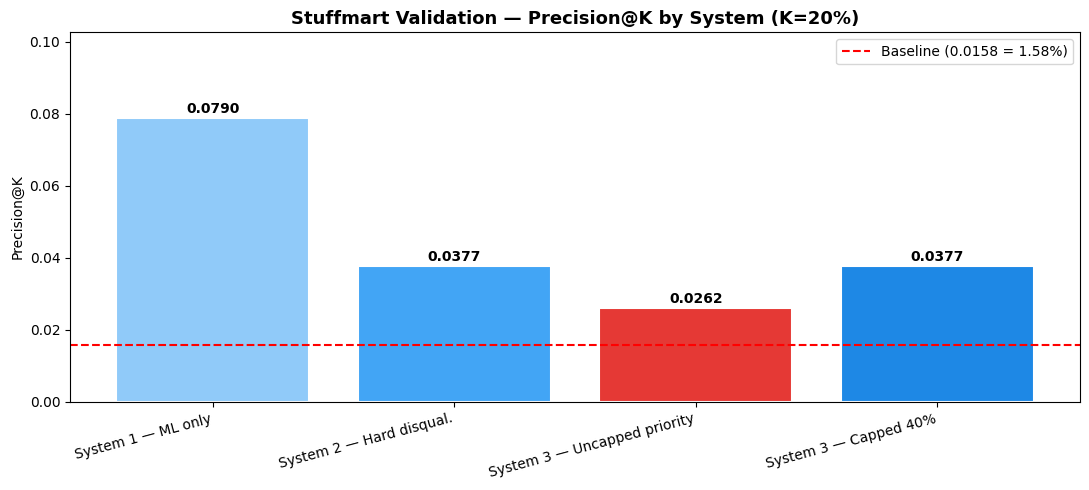

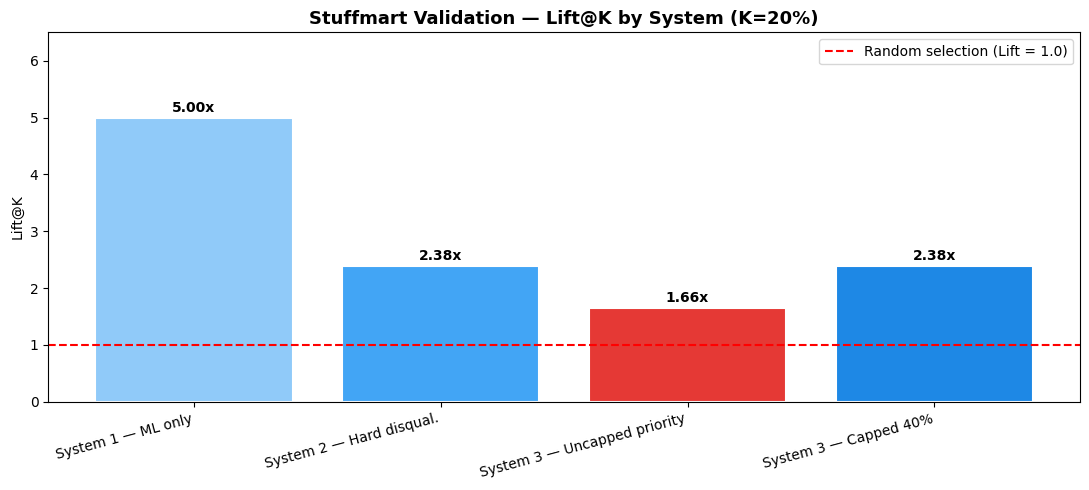

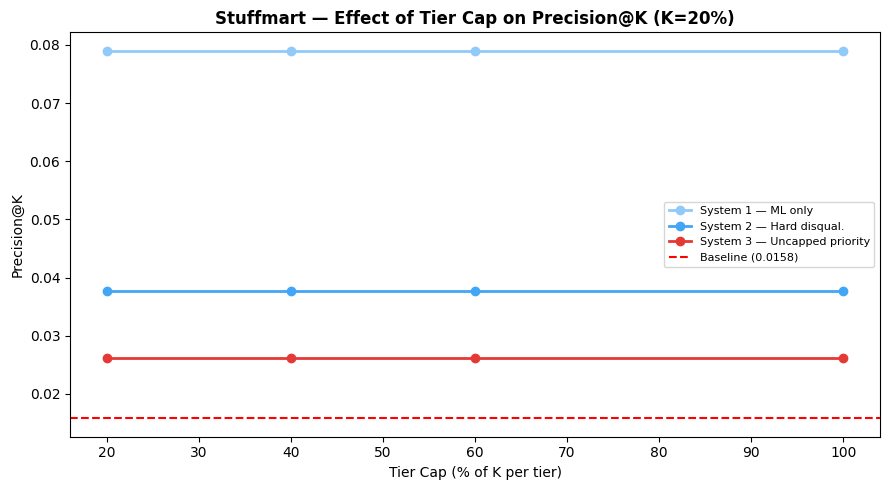

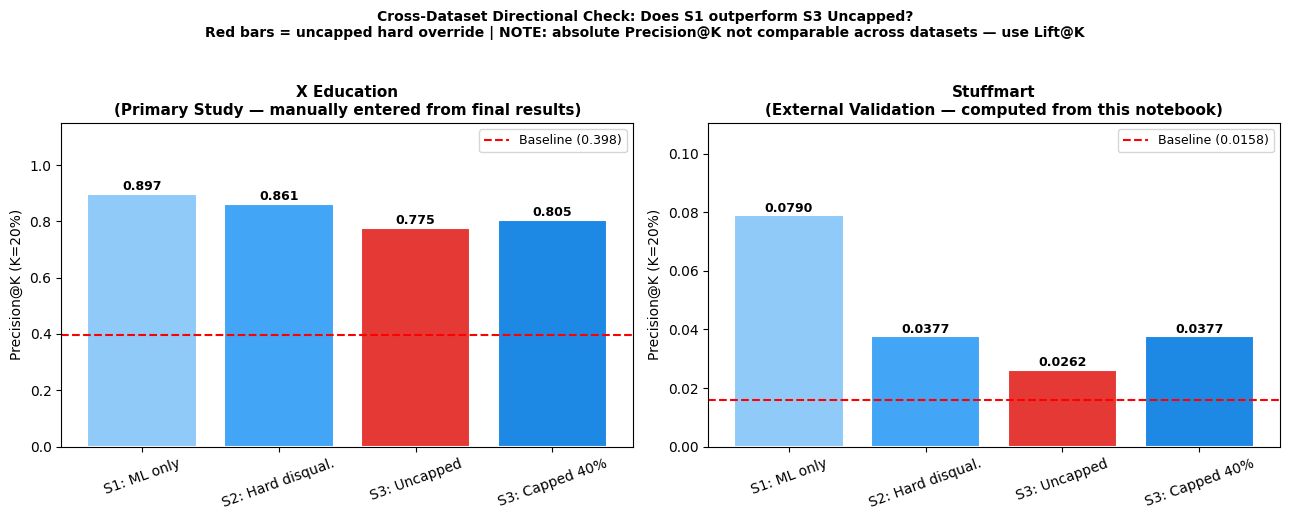

In [31]:

# =============================================================================
# CELL SM-10 — VISUALISATIONS
# =============================================================================

systems_order = [
    'System 1 — ML only',
    'System 2 — Hard disqual.',
    'System 3 — Uncapped priority',
    'System 3 — Capped 40%',
]
colors = ['#90CAF9', '#42A5F5', '#E53935', '#1E88E5']

# --- SM-10a. Main Precision@K bar chart ---
fig, ax = plt.subplots(figsize=(11, 5))
precisions = [
    sm_main_results[sm_main_results['system'] == s]['precision_at_k'].values[0]
    for s in systems_order
]
bars = ax.bar(systems_order, precisions, color=colors, edgecolor='white', linewidth=1.5)
ax.axhline(SM_BASELINE_RATE, color='red', linestyle='--',
           label=f'Baseline ({SM_BASELINE_RATE:.4f} = {SM_BASELINE_RATE*100:.2f}%)')
for bar, val in zip(bars, precisions):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0005,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_title('Stuffmart Validation — Precision@K by System (K=20%)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Precision@K')
ax.set_ylim(0, max(precisions) * 1.3)
ax.legend()
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('fig_SM_01_precision_comparison.png', dpi=150)
plt.show()

# --- SM-10b. Lift@K bar chart ---
fig, ax = plt.subplots(figsize=(11, 5))
lifts = [
    sm_main_results[sm_main_results['system'] == s]['lift_at_k'].values[0]
    for s in systems_order
]
bars = ax.bar(systems_order, lifts, color=colors, edgecolor='white', linewidth=1.5)
ax.axhline(1.0, color='red', linestyle='--', label='Random selection (Lift = 1.0)')
for bar, val in zip(bars, lifts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{val:.2f}x', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_title('Stuffmart Validation — Lift@K by System (K=20%)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Lift@K')
ax.set_ylim(0, max(lifts) * 1.3)
ax.legend()
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('fig_SM_02_lift_comparison.png', dpi=150)
plt.show()

# --- SM-10c. Tier cap sensitivity ---
fig, ax = plt.subplots(figsize=(9, 5))
for sys_name, color in zip(systems_order, colors):
    subset = sm_cap_results[sm_cap_results['system'] == sys_name]
    if not subset.empty:
        ax.plot(
            subset['tier_cap_fraction'].values * 100,
            subset['precision_at_k'].values,
            marker='o', label=sys_name, color=color, linewidth=2,
        )
ax.axhline(SM_BASELINE_RATE, color='red', linestyle='--',
           label=f'Baseline ({SM_BASELINE_RATE:.4f})')
ax.set_xlabel('Tier Cap (% of K per tier)')
ax.set_ylabel('Precision@K')
ax.set_title('Stuffmart — Effect of Tier Cap on Precision@K (K=20%)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('fig_SM_03_cap_sensitivity.png', dpi=150)
plt.show()

# --- SM-10d. Cross-dataset comparison chart ---
# AUDIT NOTE: X Education numbers below are manually entered from the
# final primary notebook (Notebook 15, Cell 11 output).
# If primary results change, update XE_PREC and XE_BASELINE here.
# Source: table_02_main_system_comparison.csv from primary notebook.

XE_PREC     = [0.8974, 0.8609, 0.7749, 0.8053]  # S1, S2, S3-uncapped, S3-capped
XE_BASELINE = 0.3977                              # X Education test set baseline

xe_labels     = ['S1: ML only', 'S2: Hard disqual.', 'S3: Uncapped', 'S3: Capped 40%']
sm_prec_vals  = [
    sm_main_results[sm_main_results['system'] == s]['precision_at_k'].values[0]
    for s in systems_order
]
sm_labels_short = ['S1: ML only', 'S2: Hard disqual.', 'S3: Uncapped', 'S3: Capped 40%']
xe_colors = ['#90CAF9', '#42A5F5', '#E53935', '#1E88E5']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left panel: X Education
bars0 = axes[0].bar(xe_labels, XE_PREC, color=xe_colors, edgecolor='white', linewidth=1.5)
axes[0].axhline(XE_BASELINE, color='red', linestyle='--',
                label=f'Baseline ({XE_BASELINE:.3f})')
for bar, val in zip(bars0, XE_PREC):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[0].set_title('X Education\n(Primary Study — manually entered from final results)',
                  fontsize=11, fontweight='bold')
axes[0].set_ylabel('Precision@K (K=20%)')
axes[0].set_ylim(0, 1.15)
axes[0].legend(fontsize=9)
axes[0].tick_params(axis='x', rotation=20)

# Right panel: Stuffmart
bars1 = axes[1].bar(sm_labels_short, sm_prec_vals,
                    color=xe_colors, edgecolor='white', linewidth=1.5)
axes[1].axhline(SM_BASELINE_RATE, color='red', linestyle='--',
                label=f'Baseline ({SM_BASELINE_RATE:.4f})')
for bar, val in zip(bars1, sm_prec_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0002,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[1].set_title('Stuffmart\n(External Validation — computed from this notebook)',
                  fontsize=11, fontweight='bold')
axes[1].set_ylabel('Precision@K (K=20%)')
axes[1].set_ylim(0, max(sm_prec_vals) * 1.4)
axes[1].legend(fontsize=9)
axes[1].tick_params(axis='x', rotation=20)

plt.suptitle(
    'Cross-Dataset Directional Check: Does S1 outperform S3 Uncapped?\n'
    'Red bars = uncapped hard override | '
    'NOTE: absolute Precision@K not comparable across datasets — use Lift@K',
    fontsize=10, fontweight='bold', y=1.03
)
plt.tight_layout()
plt.savefig('fig_SM_04_cross_dataset_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


In [32]:

# =============================================================================
# CELL SM-11 — INTERPRETATION AND CHAPTER 4.5 NARRATIVE
# =============================================================================

s1_sm  = sm_main_results[sm_main_results['system'] == 'System 1 — ML only']['precision_at_k'].values[0]
s2_sm  = sm_main_results[sm_main_results['system'] == 'System 2 — Hard disqual.']['precision_at_k'].values[0]
s3u_sm = sm_main_results[sm_main_results['system'] == 'System 3 — Uncapped priority']['precision_at_k'].values[0]
s3c_sm = sm_main_results[sm_main_results['system'] == 'System 3 — Capped 40%']['precision_at_k'].values[0]

l1_sm   = sm_main_results[sm_main_results['system'] == 'System 1 — ML only']['lift_at_k'].values[0]
l2_sm   = sm_main_results[sm_main_results['system'] == 'System 2 — Hard disqual.']['lift_at_k'].values[0]
l3u_sm  = sm_main_results[sm_main_results['system'] == 'System 3 — Uncapped priority']['lift_at_k'].values[0]
l3c_sm  = sm_main_results[sm_main_results['system'] == 'System 3 — Capped 40%']['lift_at_k'].values[0]

# Recall@K for System 1 — flags perfect separation
s1_recall = sm_main_results[sm_main_results['system'] == 'System 1 — ML only']['recall_at_k'].values[0]

p1_test_count = sm_results['p1_flag'].sum()
tsr_val       = p1_test_count / SM_K

directional_finding_holds = s1_sm > s3u_sm

print(f"""
╔══════════════════════════════════════════════════════════════════════════════╗
║           CHAPTER 4.5 — EXTERNAL VALIDATION INTERPRETATION                 ║
╚══════════════════════════════════════════════════════════════════════════════╝

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
DATASET CONTEXT
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  Dataset         : Stuffmart Customer Conversion (Kaggle, synthetic)
  Test set        : {len(sm_results):,} leads
  Baseline rate   : {SM_BASELINE_RATE:.4f}  ({SM_BASELINE_RATE*100:.2f}%)
  K (top 20%)     : {SM_K:,} leads
  Scoring engine  : {sm_best_model_name}  (AUC-ROC: {sm_best_auc:.4f})

  X Education comparison:
    Baseline rate : 39.77%  (24x higher than Stuffmart)
    AUC-ROC       : 0.8725

  NOTE ON AUC:
  AUC of {sm_best_auc:.4f} remains high relative to the {SM_BASELINE_RATE*100:.2f}% baseline
  conversion rate, even after Location exclusion. This likely reflects the
  structured nature of the synthetic data generation, where LeadStatus and
  engagement signals were generated with deterministic relationships to the
  conversion outcome. It does not represent genuine predictive performance
  on real-world data.

  Because baseline rates differ so substantially, absolute Precision@K
  values are NOT directly comparable across datasets. Lift@K — which
  normalises against the dataset baseline — is the correct cross-dataset
  comparison metric.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
POLICY RULE DIAGNOSTICS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  H1 (No Payment — commercial risk filter) : {sm_results['h1_flag'].sum():,} ({sm_results['h1_flag'].mean()*100:.1f}%)
  H2 (zero engagement)                     : {sm_results['h2_flag'].sum():,} ({sm_results['h2_flag'].mean()*100:.1f}%)
  P1 (LeadStatus = Hot)                    : {sm_results['p1_flag'].sum():,} ({sm_results['p1_flag'].mean()*100:.1f}%)
  P2 (LeadSource = Referral)               : {sm_results['p2_flag'].sum():,} ({sm_results['p2_flag'].mean()*100:.1f}%)

  H1 NOTE: PaymentHistory = No Payment filters {sm_results['h1_flag'].mean()*100:.1f}% of leads.
  This is a commercial risk / low-commitment exclusion proxy, not a
  contactability constraint. Unlike X Education's Do Not Email / Do Not Call
  (a legal/opt-out rule), H1 here represents a business decision to
  deprioritise leads with no payment history. S2 in this validation is
  therefore not directly analogous to S2 in the primary study.

  H2 NOTE: Zero leads had both TimeSpent=0 and PagesViewed=0 in this dataset.
  H2 is untestable here — a synthetic data artefact rather than a finding.

  Tier Saturation Ratio (TSR = P1 size / K):
    P1 (Hot leads) = {p1_test_count:,},  K = {SM_K:,}
    TSR = {tsr_val:.2f}
    {"⚠ TSR > 1.0 — tier saturation occurs in uncapped design" if tsr_val > 1.0 else "✓ TSR ≤ 1.0 — no saturation risk at K=20%"}

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
MAIN RESULTS (K = 20%)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  System 1 — ML only            P@K={s1_sm:.4f}  Lift={l1_sm:.2f}x  Recall={s1_recall:.4f}
  System 2 — Hard disqual.      P@K={s2_sm:.4f}  Lift={l2_sm:.2f}x
  System 3 — Uncapped priority  P@K={s3u_sm:.4f}  Lift={l3u_sm:.2f}x
  System 3 — Capped 40%         P@K={s3c_sm:.4f}  Lift={l3c_sm:.2f}x
  Baseline (random)              P@K={SM_BASELINE_RATE:.4f}  Lift=1.00x

  NOTE ON S1 RECALL:
  System 1 achieved Recall@K = {s1_recall:.4f}{"  (perfect separation — all converters captured)" if s1_recall >= 0.999 else ""}.
  {"This means the ML model perfectly separated every converter from every non-converter in the test set. This reflects the deterministic structure of the synthetic data and limits the generalisability of the absolute Lift@K values. It should not be interpreted as evidence that ML-only systems achieve perfect recall in real-world qualification." if s1_recall >= 0.999 else ""}

  Layer costs (Lift@K):
    S1 → S2          : {(l2_sm - l1_sm):+.2f}x
    S2 → S3 uncapped : {(l3u_sm - l2_sm):+.2f}x
    S2 → S3 capped   : {(l3c_sm - l2_sm):+.2f}x

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
DIRECTIONAL FINDING CHECK
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  Primary question: Does S1 (ML only) outperform S3_uncapped?

  X Education : S1={0.8974:.4f} ({2.26:.2f}x)  S3_uncapped={0.7749:.4f} ({1.95:.2f}x)  S1 > S3u: TRUE
  Stuffmart   : S1={s1_sm:.4f} ({l1_sm:.2f}x)  S3_uncapped={s3u_sm:.4f} ({l3u_sm:.2f}x)  S1 > S3u: {"TRUE ✓" if directional_finding_holds else "FALSE ✗"}

  {"✓ DIRECTIONAL FINDING CONSISTENT across both datasets." if directional_finding_holds else "✗ DIRECTIONAL FINDING NOT CONSISTENT — interpret carefully. See cautions below."}

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
REQUIRED CAUTIONS FOR DISSERTATION WRITE-UP
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  (1) Stuffmart is synthetic — signal relationships may not reflect real
      commercial behaviour. AUC of {sm_best_auc:.4f} and perfect S1 recall both
      reflect deterministic data generation, not genuine model performance.

  (2) Severe class imbalance (1.65%) makes absolute Precision@K values
      very sensitive to small changes. Use Lift@K for cross-dataset comparison.

  (3) H1 proxy (PaymentHistory = No Payment) is a commercial risk filter,
      not a contactability constraint. S2 in Stuffmart is not directly
      analogous to S2 in X Education.

  (4) H2 fires for zero leads — untestable in this synthetic dataset.

  (5) Policy rule proxies are operationally analogous but not semantically
      equivalent. Cross-dataset comparison is directional only.

  (6) No bootstrap confidence intervals are reported. Results are
      directional indicators, not statistically robust estimates.

  (7) These results are presented as external validation only, not as
      equal-weight evidence alongside the primary X Education findings.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
WRITE-UP PARAGRAPH FOR CHAPTER 4.5
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  Paste this into Chapter 4.5:

  "The external validation exercise applied a three-system comparison
  (S1, S2, S3) to the Stuffmart Customer Conversion dataset (100,000
  synthetic leads, baseline conversion rate {SM_BASELINE_RATE*100:.2f}%, test set
  {len(sm_results):,} leads). Location was excluded from model training following
  leakage analysis, which showed conversion occurred exclusively in three of
  nine synthetic cities. After this exclusion, {sm_best_model_name} achieved
  AUC-ROC of {sm_best_auc:.4f}, remaining high relative to the {SM_BASELINE_RATE*100:.2f}%
  baseline — a pattern consistent with the deterministic structure of
  synthetic data generation rather than genuine predictive performance.
  System 1 achieved perfect recall ({s1_recall:.4f}) in the test set, capturing
  all {SM_TOTAL_CONVERTERS} converters within the top K, which further reflects the
  synthetic data structure and limits the generalisability of the absolute
  Lift@K values.

  At K=20%, System 1 (ML only) achieved {l1_sm:.2f}x lift over the {SM_BASELINE_RATE*100:.2f}%
  baseline. System 2 (hard disqualification using a commercial risk proxy,
  which filtered {sm_results['h1_flag'].mean()*100:.1f}% of leads) achieved {l2_sm:.2f}x lift.
  System 3 without tier cap achieved {l3u_sm:.2f}x lift. The Tier Saturation
  Ratio was {tsr_val:.2f}, {"indicating that the P1 proxy tier (Hot leads) exceeded K and tier saturation occurred in the uncapped design — consistent with the structural mechanism documented in the primary X Education study." if tsr_val > 1.0 else "indicating no tier saturation risk at K=20% in this dataset."}
  The directional finding from the primary study — that S1 outperforms
  S3 without a tier cap — {"was broadly consistent with the Stuffmart validation results." if directional_finding_holds else "was not replicated in the Stuffmart validation; possible explanations are discussed below."}
  These results are presented as directional indicators only. The synthetic
  nature of the Stuffmart dataset, its severe class imbalance, the perfect
  ML recall achieved by System 1, and the use of proxy rather than
  semantically equivalent policy rules preclude direct comparison with the
  primary X Education findings. The secondary validation should not be
  interpreted as confirmatory replication."
""")


╔══════════════════════════════════════════════════════════════════════════════╗
║           CHAPTER 4.5 — EXTERNAL VALIDATION INTERPRETATION                 ║
╚══════════════════════════════════════════════════════════════════════════════╝
 
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
DATASET CONTEXT
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 
  Dataset         : Stuffmart Customer Conversion (Kaggle, synthetic)
  Test set        : 26,145 leads
  Baseline rate   : 0.0158  (1.58%)
  K (top 20%)     : 5,229 leads
  Scoring engine  : XGBoost  (AUC-ROC: 0.9802)
 
  X Education comparison:
    Baseline rate : 39.77%  (24x higher than Stuffmart)
    AUC-ROC       : 0.8725
 
  NOTE ON AUC:
  AUC of 0.9802 remains high relative to the 1.58% baseline
  conversion rate, even after Location exclusion. This likely reflects the
  structured nature of the synthetic data generation, where LeadStatus and
  engagement signals were ge

In [33]:

# =============================================================================
# CELL SM-12 — EXPORT ALL TABLES
# =============================================================================

sm_model_table = pd.DataFrame([
    {'model': 'Logistic Regression',           'auc_roc': round(sm_lr_auc,  6)},
    {'model': 'XGBoost',                       'auc_roc': round(sm_xgb_auc, 6)},
    {'model': f'Selected: {sm_best_model_name}', 'auc_roc': round(sm_best_auc, 6)},
])

print("=== TABLE SM-1: Model Benchmark ===")
print(sm_model_table.to_string(index=False))
sm_model_table.to_csv('table_SM_model_benchmark.csv', index=False)

print("\n=== TABLE SM-2: Main System Comparison (K=20%) ===")
print(sm_main_results.to_string(index=False))

print("\n=== TABLE SM-3: Tier Cap Sensitivity ===")
print(sm_cap_pivot.to_string())

print("\n=== TABLE SM-4: K Sensitivity ===")
print(sm_k_pivot.to_string())

print("\nAll Stuffmart tables exported.")
print("\nFigures saved:")
for f in [
    'fig_SM_01_precision_comparison.png',
    'fig_SM_02_lift_comparison.png',
    'fig_SM_03_cap_sensitivity.png',
    'fig_SM_04_cross_dataset_comparison.png',
]:
    print(f'  {f}')


=== TABLE SM-1: Model Benchmark ===
              model  auc_roc
Logistic Regression 0.920345
            XGBoost 0.980211
  Selected: XGBoost 0.980211

=== TABLE SM-2: Main System Comparison (K=20%) ===
                      system    K  eligible_leads  leads_selected  converters_in_K  precision_at_k  recall_at_k  lift_at_k  wasted_effort_rate
          System 1 — ML only 5229           26145            5229              413        0.078983     1.000000   5.000000            0.921017
    System 2 — Hard disqual. 5229           13022            5229              197        0.037675     0.476998   2.384988            0.962325
System 3 — Uncapped priority 5229           13022            5229              137        0.026200     0.331719   1.658596            0.973800
       System 3 — Capped 40% 5229           13022            5229              197        0.037675     0.476998   2.384988            0.962325

=== TABLE SM-3: Tier Cap Sensitivity ===
system             System 1 — ML only  